In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import copy
from datetime import datetime
import plotly.graph_objects as go
from scipy.stats import linregress
from IPython.display import Image
import fitz

In [2]:
carbon_colors = { 'points' : '#a7c957' , 'fitline' : '#42512a' , 'trendline':'#a7c957', 'future' : '#6a994e'}
colors_dict = {'Coal': '#ff9f6e',
 'Natural Gas': '#ffc285',
 'Biomass': '#ffe5b4',
 'Geothermal': '#f66d44',
 'Solar': '#d64f3b',
 'Hydropower': '#a83d3b',
 'Nuclear': '#6d2e46',
 'Wind': '#401d3d'}

In [3]:
energy_unit_map_AI = {
    1e-3:  '1 mJ',           # millijoule
    1:     '1 J',            # joule
    1e3:   '1 kJ',           # kilojoule
    1e6:   '1 MJ',           # megajoule
    1e9:   '1 GJ',           # gigajoule
    1e12:  '1 TJ',           # terajoule
    1e15:  '1 PJ',           # petajoule
    1e18:  '1 EJ',           # exajoule
    1e21:  '1 ZJ',           # zettajoule
    1e24:  '1 YJ'            # yottajoule
}
mass_unit_map_AI = {
    1e-9:  '1 μg',          # microgram
    1e-6:  '1 mg',          # milligram
    1e-3:  '1 g',           # gram
    1:     '1 kg',          # kilogram
    1e3:   '1000 kg',       # megagram (metric ton)
    1e6:   '1e6 kg',        #'10⁶ kg',  # gigagram
    1e9:   '1e9 kg',        #'10⁹ kg',  # teragram
    1e12:  '1e12 kg',       #'10¹² kg', # petagram
    1e15:  '1e15 kg',       # exagram
    1e18:  '1e18 kg',       # zettagram
    1e21:  '1e21 kg'        # yottagram
}

energy_unit_map_BM = {
    1e-6:  '1 μJ',
    1e-3:  '1 mJ',          # millijoule
    1:     '1 J',           # joule
    1e3:   '1 kJ',          # kilojoule
    1e6:   '1 MJ',          # megajoule
    1e9:   '1 GJ',          # gigajoule
    1e10:  '1e10 J',
    1e12:  '1e12 J',        # terajoule
    1e14:  '1e14 J',
    1e15:  '1e15 J',        # petajoule
    1e16:  '1e16 J',
    1e18:  '1 EJ',          # exajoule
    1e20:  '1e20',
    1e21:  '1 ZJ',          # zettajoule
    1e24:  '1 YJ',          # yottajoule
    1e27:  '1e27 J'
}

mass_unit_map_BM = {
    1e-9:  '1 μg',        # microgram
    1e-6:  '1 mg',        # milligram
    1e-3:  '1 g',         # gram
    1:     '1 kg',        # kilogram
    1e3:   '1e3 kg',      # megagram (metric ton)
    1e6:   '1e6 kg',      # gigagram
    1e9:   '1e9 kg',      # teragram
    1e12:  '1e12 kg',     # petagram
    1e15:  '1e15 kg',     # exagram
    1e18:  '1e18 kg',     # zettagram
    1e21:  '1e21 kg'      # yottagram
}


factor_KGperJ_to_GperKWH = 3.6e9        # 1 kg/J = 3.6 G/kWh


In [4]:
def merge_dfs(data_frames, on,how='outer'):
    df_merged = reduce(lambda  left,right: pd.merge(left,right,on=on, how=how), data_frames)
    return df_merged

### Total CO2 emissions in USA
#### 2022: 
- 6,343 million metric tons = 6.343e12 kg 
- https://www.epa.gov/ghgemissions/inventory-us-greenhouse-gas-emissions-and-sinks

#### 2024: 
- 5912.62 Mt CO2e ==> https://edgar.jrc.ec.europa.eu/report_2025

#### 2025: 
- 7.01 Mt CO2e ==> https://climatetrace.org/news/climate-trace-data-show-global-greenhouse-gas-emissions-hit-a-new-record-high-in-2025


In [6]:
## 2024
total_USA_CO2emissions_year = 2024
total_USA_CO2emissions = 5.912e12 ## kg CO2e

### Carbon Intensity of Electricity Generation in USA
- Carbon Intensity of electricity generation from Our World In Data: https://ourworldindata.org/grapher/carbon-intensity-electricity  

In [7]:
carbonintensity = pd.read_csv('data/carbon-intensity-electricity_OurWorldInData.csv')
carbonintensity = carbonintensity[carbonintensity['Code'] == 'USA'].copy()
factor = 1 / 3.6e+9  # Convert from gCO2e/kWh to kgCO2e/J
carbonintensity_USA = carbonintensity[['Year']].copy()
carbonintensity_USA['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]'] = (
    carbonintensity['Carbon intensity of electricity - gCO2e/kWh'] * factor
)

carbonintensity_USA = carbonintensity_USA.set_index('Year')


### Carbon Intensity of different Energy Sources 
- IPCC 2018 report ---> https://www.ipcc.ch/site/assets/uploads/2018/02/ipcc_wg3_ar5_annex-iii.pdf
- Using the median values for a given energy source, and using the smallest median value if different types of the same energy source are present 

In [8]:
energysourcescarbonintensity = pd.read_csv('data/CarbonIntensity_DifferentEnergySources.csv')
factor_GperKWH_to_KGperJ = 1/3.6e9  ## Convert from gCO2e/kWH to kgCO2e/J
energysourcescarbonintensity['Median Carbon Intensity [kg CO2e/J]'] = energysourcescarbonintensity['Median Carbon Intensity [g CO2e/kWh]']*factor_GperKWH_to_KGperJ

---

## AI

### AI Hardware
- Chip Dataset: https://chip-dataset.vercel.app/
- Epoch AI ML hardware data: https://epoch.ai/data

In [9]:
### Chip Dataset GPU Hardware

chipdataset = pd.read_csv('data/chip_dataset.csv')
chipdataset = chipdataset[chipdataset['Type']=='GPU']
chipdataset['TDP (W)'] = pd.to_numeric(chipdataset['TDP (W)'], errors='coerce')
chipdataset = chipdataset.dropna(subset=['Release Date', 'TDP (W)', 'FP32 GFLOPS'])

chipdataset['Product Release Year'] = '20' + chipdataset['Release Date'].str[-2:]
chipdataset['Product Release Year'] = chipdataset['Product Release Year'].astype(int)
chipdataset['Model Year'] = chipdataset['Product Release Year'] + 1

chipdataset['FP32 FLOPS'] = chipdataset['FP32 GFLOPS'] * (10**9)
chipdataset['TDP (W)'] = chipdataset['TDP (W)'].astype(float)
chipdataset['Energy/FLOP [W/FLOPS] [J/FLOP]'] = chipdataset['TDP (W)']/chipdataset['FP32 FLOPS']

chipdataset_cleaned = chipdataset[['Type', 'Product Release Year', 'Model Year', 'Product', 'TDP (W)', 'FP32 FLOPS', 'Energy/FLOP [W/FLOPS] [J/FLOP]']]

bestchip = chipdataset_cleaned.loc[chipdataset_cleaned.groupby('Product Release Year')['FP32 FLOPS'].idxmax()]



In [10]:
### Epoch AI ML Hardware (including GPUs and Accelerators)

mlhardware = pd.read_csv('data/ml_hardware.csv')

mlhardware = mlhardware[mlhardware['Type']=='GPU']
mlhardware['TDP (W)'] = pd.to_numeric(mlhardware['TDP (W)'], errors='coerce')
mlhardware = mlhardware.dropna(subset=['Release date', 'TDP (W)', 'FP32 (single precision) performance (FLOP/s)' ])

mlhardware['Product Release Year'] = mlhardware['Release date'].str[:4]
mlhardware['Product Release Year'] = mlhardware['Product Release Year'].astype(int)
mlhardware['Model Year'] = mlhardware['Product Release Year'] + 1

mlhardware['Energy/FLOP [W/FLOPS] [J/FLOP]'] = mlhardware['TDP (W)']/mlhardware['FP32 (single precision) performance (FLOP/s)']

mlhardware = mlhardware.rename(columns={'Hardware name': 'Product', 
                                        'FP32 (single precision) performance (FLOP/s)': 'FP32 FLOPS'})

mlhardware_cleaned = mlhardware[['Type', 'Product Release Year', 'Model Year', 'Product', 'TDP (W)','FP32 FLOPS', 'Energy/FLOP [W/FLOPS] [J/FLOP]']]

bestmlhardware = mlhardware_cleaned.loc[mlhardware_cleaned.groupby('Product Release Year')['FP32 FLOPS'].idxmax()]



In [11]:
### Combining Chip Dataset and ML Hardware Data and finding the best hardware per year based on FP32 FLOPS 

combined_chip_mlhardware = pd.concat([mlhardware_cleaned, chipdataset_cleaned])

combined_chip_mlhardware = combined_chip_mlhardware.drop_duplicates(subset=['Product','TDP (W)','FP32 FLOPS'], keep='first')

best_combined_chip_mlhardware = combined_chip_mlhardware.loc[combined_chip_mlhardware.groupby('Product Release Year')['FP32 FLOPS'].idxmax()]


## AI Models
- Epoch AI -- All AI Models data: https://epoch.ai/data

In [12]:
all_ai_models = pd.read_csv('data/all_ai_models.csv')
all_ai_models = all_ai_models.dropna(subset=['Publication date', 'Training compute (FLOP)'])

all_ai_models['Model Year'] = all_ai_models['Publication date'].str[:4].astype(int)
all_ai_models = all_ai_models[['Model Year', 'Model', 'Domain', 'Training compute (FLOP)', 'Training time (hours)', 
                                       'Training hardware', 'Hardware quantity']]
all_ai_models_cleaned = all_ai_models[['Model Year', 'Model', 'Training compute (FLOP)']]

bestaimodel = all_ai_models_cleaned.loc[all_ai_models_cleaned.groupby('Model Year')['Training compute (FLOP)'].idxmax()]
bestaimodel.reset_index(inplace=True)   
bestaimodel.drop(columns=['index'],inplace=True)

best_combined_notable_large_models = bestaimodel


In [13]:
best_combined_notable_large_models

,Model Year,Model,Training compute (FLOP)
0,1950,Theseus,4.000000e+01
1,1957,Perceptron Mark I,6.948949e+05
2,1959,Pandemonium (morse),6.000000e+08
3,1960,Perceptron (1960),7.200000e+08
4,1962,Linear Decision Functions,1.559250e+06
5,1963,Print Recognition Logic,2.250000e+07
6,1965,Heuristic Reinforcement Learning,1.080000e+06
7,1966,LTE speaker verification system,1.059171e+08
8,1975,Cognitron,5.184000e+06
9,1980,Neocognitron,2.737382e+08


### Combining AI hardware and AI models data 
- considering the best AI model from a given year runs on the best AI hardware from the previous year

In [14]:
### Merging Best Hardware and Best Models Dataframes

data_combined_models_hardwares = merge_dfs([best_combined_chip_mlhardware, best_combined_notable_large_models], 'Model Year', 'inner')


In [15]:
data_combined_models_hardwares['Product']

0              ATI Xbox 360 GPU 90nm
1            NVIDIA GeForce 8800 GTX
2                AMD FireStream 9170
3                AMD FireStream 9270
4                 ATI Radeon HD 5870
5                  ATI FirePro V9800
6                 AMD Radeon HD 7970
7     AMD Radeon HD 7970 GHz Edition
8                 AMD Radeon R9 290X
9                   NVIDIA Tesla K80
10                  NVIDIA TESLA M60
11               NVIDIA Quadro P6000
12            NVIDIA Tesla V100 SXM2
13               NVIDIA Quadro GV100
14     NVIDIA Tesla V100S PCIe 32 GB
15                  NVIDIA RTX A6000
16        AMD Radeon Instinct MI250X
17                Huawei Ascend 910B
18               AMD Instinct MI300X
19               AMD Instinct MI325X
20                  Amazon Trainium3
Name: Product, dtype: object

In [16]:
### Calculating the Training Compute (FLOP) for 2035 based on median Year on Year Change in Training Compute (FLOP).
### This is done by calculating the median Year on Year Change in Training Compute (FLOP) from Model Years 2006 to 2025 
### and then applying that change to the last known value in 2025 to estimate the value for 2035.

col = 'Training compute (FLOP)'
last_year, next_year = 2025, 2035

sliced_data_combined_models_hardwares = data_combined_models_hardwares[data_combined_models_hardwares['Model Year'] <= last_year].copy()
sliced_data_combined_models_hardwares[f'yoy_change {col}'] = sliced_data_combined_models_hardwares[col].pct_change()
median_yoyFLOP = sliced_data_combined_models_hardwares[f'yoy_change {col}'].median()

print(f"Median Year on Year Change in Training Compute (FLOP): {median_yoyFLOP:.2%}")


last_FLOP = sliced_data_combined_models_hardwares.loc[sliced_data_combined_models_hardwares['Model Year'] == last_year, 'Training compute (FLOP)'].values[0]
next_FLOP = last_FLOP * ((1 + median_yoyFLOP)**(next_year-last_year))

print(f"({last_year}) Training Compute (FLOP): {last_FLOP:.2e}")
print(f"({next_year}) Training Compute (FLOP): {next_FLOP:.2e}")


Median Year on Year Change in Training Compute (FLOP): 551.91%
(2025) Training Compute (FLOP): 5.00e+26
(2035) Training Compute (FLOP): 6.93e+34


## Energy Consumption

In [17]:
totalenergy_AI = copy.deepcopy(data_combined_models_hardwares)
totalenergy_AI['Energy/model [J]'] = totalenergy_AI['Energy/FLOP [W/FLOPS] [J/FLOP]']*totalenergy_AI['Training compute (FLOP)']

energy2020 = totalenergy_AI[totalenergy_AI['Model Year']==2020]['Energy/model [J]'].values[0]
energy2025 = totalenergy_AI[totalenergy_AI['Model Year']==2025]['Energy/model [J]'].values[0]
ratio = energy2025/energy2020
print(f"Energy Consumption in 2025 is {ratio:.2f} times that of 2020")

Energy Consumption in 2025 is 637.33 times that of 2020


In [18]:
totalenergy_AI

,Type,Product Release Year,Model Year,Product,TDP (W),FP32 FLOPS,Energy/FLOP [W/FLOPS] [J/FLOP],Model,Training compute (FLOP),Energy/model [J]
0,GPU,2005,2006,ATI Xbox 360 GPU 90nm,203.0,2.400000e+11,8.458333e-10,SVM-CNN,7.452000e+14,6.303150e+05
1,GPU,2006,2007,NVIDIA GeForce 8800 GTX,155.0,3.456000e+11,4.484954e-10,SB-LM,1.449446e+18,6.500700e+08
2,GPU,2007,2008,AMD FireStream 9170,105.0,4.973000e+11,2.111402e-10,GNN,1.614600e+09,3.409069e-01
3,GPU,2008,2009,AMD FireStream 9270,160.0,1.200000e+12,1.333333e-10,Conditional Maximum Entropy Model (Gigaworld),1.000000e+18,1.333333e+08
4,GPU,2009,2010,ATI Radeon HD 5870,188.0,2.720000e+12,6.911765e-11,RNN LM,5.396000e+16,3.729588e+06
5,GPU,2010,2011,ATI FirePro V9800,250.0,2.720000e+12,9.191176e-11,CNN Committee (MNIST),5.200000e+16,4.779412e+06
6,GPU,2011,2012,AMD Radeon HD 7970,250.0,3.789000e+12,6.598047e-11,Unsupervised High-level Feature Learner,6.000000e+17,3.958828e+07
7,GPU,2012,2013,AMD Radeon HD 7970 GHz Edition,300.0,4.301000e+12,6.975122e-11,DistBelief NNLM,2.612736e+18,1.822415e+08
8,GPU,2013,2014,AMD Radeon R9 290X,290.0,5.632000e+12,5.149148e-11,SNM-skip,2.976000e+20,1.532386e+10
9,GPU,2014,2015,NVIDIA Tesla K80,300.0,8.126000e+12,3.691853e-11,AlphaGo Fan,3.800000e+20,1.402904e+10


Fitted equation: log(y) = -0.1301 log(x) + -17.9172


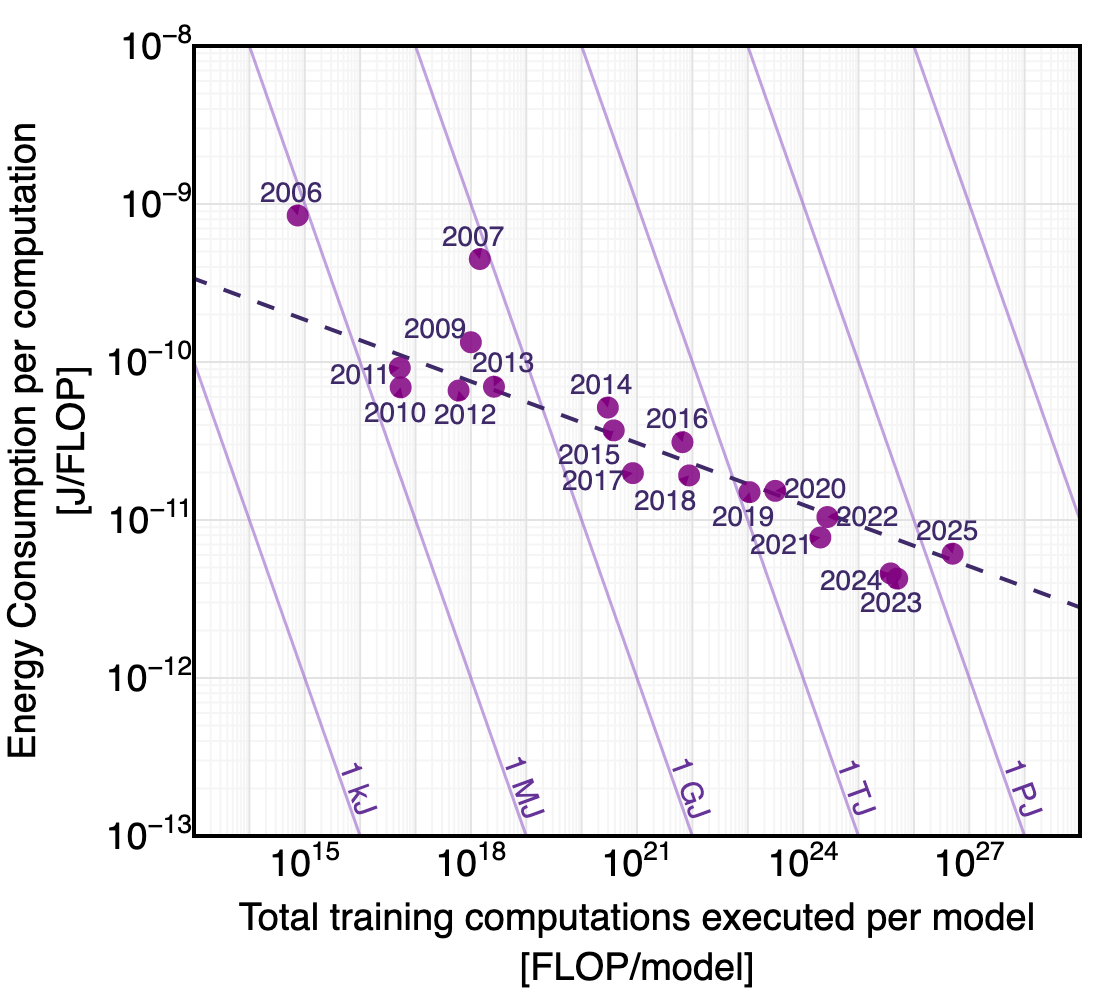

In [19]:
### Total Energy Consumption graph for the best model in the current year running on the best hardware from the previous years


data = totalenergy_AI[(totalenergy_AI['Model Year']>2005) & (totalenergy_AI['Model Year']<2026)].reset_index()

y_axis = 'Energy/FLOP [W/FLOPS] [J/FLOP]'
x_axis = 'Training compute (FLOP)'

fig = go.Figure()

minx, maxx = 13, 29
miny, maxy = -13, -8

#########################################################################################################################

def add_major_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color="#E3E3E3", y_color="#E3E3E3", width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        val = 10 ** exp
        xlines.append(go.Scatter(
            x=[val, val],
            y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
            mode='lines',
            line=dict(color=x_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        val = 10 ** exp
        ylines.append(go.Scatter(
            x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
            y=[val, val],
            mode='lines',
            line=dict(color=y_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

def add_minor_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color="#F5F5F5", y_color="#F5F5F5", width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            xlines.append(go.Scatter(
                x=[val, val],
                y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
                mode='lines',
                line=dict(color=x_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            ylines.append(go.Scatter(
                x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
                y=[val, val],
                mode='lines',
                line=dict(color=y_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

add_minor_log_gridlines(fig)
add_major_log_gridlines(fig)

#########################################################################################################################


def generate_datapoints(x, y, val, n=10):
    xpoints = []
    ypoints = []
    for i in range(1, 4 * n + 1):
        xpoints.append(x * (2 ** i))
        ypoints.append(y / (2 ** i))
    for i in range(1, n + 1):
        xpoints.append(x / (2 ** i))
        ypoints.append(y * (2 ** i))

    log_xpoints = np.log(xpoints)
    log_ypoints = np.log(ypoints)

    slope_points, intercept_points, r_value_points, p_value_points, std_err_points = linregress(log_xpoints, log_ypoints)

    # print(f"Trendline for unit Elasticity equation: log(y) = {slope_points:.4f} log(x) + {intercept_points:.4f}")

    ypoints_annotate = 2*10e-14
    xpoints_annotate = val/ypoints_annotate

    return xpoints, ypoints, xpoints_annotate, ypoints_annotate

energyvals = []
for i in range(-3, 21, 3):   ## powers of e 
    energyvals.append(10**i)

for val in energyvals:
    x, y2, xpoints_annotate, ypoints_annotate = generate_datapoints(1e1, val/1e1, val, n=40)
    fig.add_trace(go.Scatter(
        x=x,
        y=y2,
        mode='lines',
        line=dict(color='#9966cc', dash='solid', width=1.5),
        name=f'Trendline {val}',
        opacity=0.6,
        yaxis = "y1" 
    ))
    fig.add_annotation(
        x=np.log10(xpoints_annotate)+0.25,
        y=np.log10(ypoints_annotate),
        text=f"{energy_unit_map_AI[val]}",
        font=dict(size=15, color='#663399'),
        showarrow=False,
        textangle=70,
    )


#########################################################################################################################


log_x = np.log(data[x_axis])
log_y = np.log(data[y_axis])

slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

b = -slope 
a = intercept

print(f"Fitted equation: log(y) = {slope:.4f} log(x) + {intercept:.4f}")
ai_models__energy__fitline_dict = {'slope': slope, 'intercept': intercept, 'fitline': f'log(y) = {slope:.4f} log(x) + {intercept:.4f}',
                          'r_value': r_value, 'p_value': p_value, 'std_err': std_err}

x_fit = np.linspace((2**66)*min(data[x_axis]), max(data[y_axis]), 100)
y_fit = np.exp(a) * x_fit**(-b)  

fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color='#3f2a69', dash='dash'),
    name='Fitline'
))


#########################################################################################################################


fig.add_trace(go.Scatter(
    x=data[x_axis],
    y=data[y_axis],
    mode='markers',
    marker=dict(color='purple', size=11, opacity=0.85),
    name='Data Points'
))



#########################################################################################################################


for i in range(len(data)):
    up = [2006, 2014, 2016, 2007, 2008, 2025]
    down = [2023, 2021, 2010, 2019] 

    arx, ary = 0, 0
    if int(data['Model Year'][i]) in up:
        arx, ary = -3,-12
    if int(data['Model Year'][i]) in down:
        arx, ary = -3,12
    if int(data['Model Year'][i]) in [2009]:
        arx, ary = -18,-7
    if int(data['Model Year'][i]) in [2011, 2017, 2021, 2024]:
        arx, ary = -20, 3 #5, -10
    if int(data['Model Year'][i]) in [2012]:
        arx, ary = 3,12
    if int(data['Model Year'][i]) in [2013]:
        arx, ary = 5,-12
    # if int(data['Model Year'][i]) in [2017]:
    #     arx, ary = 7,-12
    if int(data['Model Year'][i]) in [2022, 2020]:
        arx, ary = 20, -1
    if int(data['Model Year'][i]) in [2015, 2018]:
        arx, ary = -12,12

    fig.add_annotation(
        x=np.log10(data[x_axis][i]),
        y=np.log10(data[y_axis][i]),
        text=str(data['Model Year'][i]),
        showarrow=True,
        arrowhead=2,
        ax=arx,
        ay=ary,
        font=dict(size=14, color='#3f2a69'), 
        arrowcolor='purple'  #'black'
    )



#########################################################################################################################

fig.update_layout(
    width=550,  
    height=500,
    xaxis=dict(
        type='log',
        exponentformat="power",
        showexponent="all",
        title=dict(
            text=  'Total training computations executed per model<br>[FLOP/model]',
            standoff=10,
            font=dict(size=19)),
        range=[minx, maxx],
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=15)
    ),
    yaxis=dict(
        type='log',
        dtick=1,
        exponentformat="power",
        showexponent="all",
        title=dict(
            text=  'Energy Consumption per computation<br>[J/FLOP]',
            standoff=5,
            font=dict(size=19)),
        range=[miny, maxy], 
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=15)
    ),
    font=dict(family='Helvetica', size=10, color='black'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=10, r=10, t=10, b=10),
    
    shapes=[dict(
        type='rect',
        x0=0, x1=1, y0=0, y1=1,
        xref='paper', yref='paper',
        line=dict(color='black', width=2)
    )]
)

filename = "graphs/ai__energy_consumption"
fig.write_image(f"{filename}.png", scale=2)
fig.write_image(f"{filename}.pdf", scale=2)

display(Image(filename=f"{filename}.png"))

In [20]:
### Elasticity of Computational Demand for Energy Consumption
elasticity_energy = 1/ai_models__energy__fitline_dict['slope']
print(f"Elasticity of Computational Demand for Energy Consumption: {abs(elasticity_energy):.4f}")

Elasticity of Computational Demand for Energy Consumption: 7.6884


## Carbon Footprint

In [21]:
### Total Carbon Emissions Calculation for the best model in the current year running on the best hardware from the previous years

carbonintensity_USA.index.name = 'Model Year'
totalcarbon_AI = merge_dfs([totalenergy_AI, carbonintensity_USA], 'Model Year', 'inner')
totalcarbon_AI['Carbon Efficiency [kg CO2e/FLOP]'] = totalcarbon_AI['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']*totalcarbon_AI['Energy/FLOP [W/FLOPS] [J/FLOP]']
totalcarbon_AI['Carbon/model [kg CO2e]'] = totalcarbon_AI['Carbon Efficiency [kg CO2e/FLOP]']*totalcarbon_AI['Training compute (FLOP)']
    

In [22]:
### Projecting improvements needed in carbon intensity and carbon efficiency 
### if we want to keep the total carbon emissions constant, equivalent to the total carbon emissions in 2006

cuttoffYear = 2006
def projection_AI(totalcarbon, cuttoffYear):
    idealtotalcarbon = totalcarbon[totalcarbon['Model Year']==cuttoffYear]['Carbon/model [kg CO2e]'].values[0]

    projectioncarbon = copy.deepcopy(totalcarbon)
    projectioncarbon = projectioncarbon[projectioncarbon['Model Year']>=cuttoffYear]
    projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'] = idealtotalcarbon/projectioncarbon['Energy/model [J]']
    projectioncarbon['Projected Carbon Efficiency [kg CO2e/FLOP]'] = projectioncarbon['Energy/FLOP [W/FLOPS] [J/FLOP]']*projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']
    projectioncarbon['Ratio in Carbon Intensity of USA Grid to Projected'] = projectioncarbon['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']/(projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'])
    return projectioncarbon

projectioncarbon_AI = projection_AI(totalcarbon_AI, cuttoffYear)

In [23]:
### Required annual improvement in carbon intensity of the electricity grid to keep total carbon emissions constant

analysecarbonintensity_AI = projectioncarbon_AI[['Product Release Year', 'Model Year', 'USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]','Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']].copy()
analysecarbonintensity_AI['USA Average Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_AI['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']*factor_KGperJ_to_GperKWH
analysecarbonintensity_AI['Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_AI['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']*factor_KGperJ_to_GperKWH

analysecarbonintensity_AI['yoy_change Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_AI['Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'].pct_change()
analysecarbonintensity_AI['yoy_change Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'] = analysecarbonintensity_AI['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'].pct_change()

median_yoychange_projectedcarbonintensity = analysecarbonintensity_AI['yoy_change Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'].median()
print(f"Median Year on Year Change in Projected Carbon Intensity of Electricity Grid: {median_yoychange_projectedcarbonintensity:.2%}")



Median Year on Year Change in Projected Carbon Intensity of Electricity Grid: -78.28%


In [24]:

### Actual Year on Year Change in USA Average Carbon Intensity of Electricity Grid

analysecarbonintensity_AI['yoy_change USA Average Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_AI['USA Average Carbon Intensity of Electricity Grid [g CO2e/kWh]'].pct_change()
mean_yoychange_USAaveragecarbonintensity = analysecarbonintensity_AI['yoy_change USA Average Carbon Intensity of Electricity Grid [g CO2e/kWh]'].mean()
print(f"Mean Year on Year Change in USA Average Carbon Intensity of Electricity Grid: {mean_yoychange_USAaveragecarbonintensity:.2%}")

Mean Year on Year Change in USA Average Carbon Intensity of Electricity Grid: -2.25%


In [25]:
### Carbon efficiency of different energy sources 
carbonDiffEnergySources_AI = copy.deepcopy(totalcarbon_AI)

for i, source in enumerate(list(energysourcescarbonintensity['Source'])):
    ci_source = energysourcescarbonintensity[energysourcescarbonintensity['Source']==source]['Median Carbon Intensity [kg CO2e/J]'].values[0]
    carbonDiffEnergySources_AI[f'{source} Carbon Efficiency [kg CO2e/FLOP]'] = carbonDiffEnergySources_AI['Energy/FLOP [W/FLOPS] [J/FLOP]']*ci_source


USA Grid --- Fitted equation: log(y) = -0.1443 log(x) + -33.0646
Solar --- Fitted equation: log(y) = -0.1301 log(x) + -36.6256
Nuclear --- Fitted equation: log(y) = -0.1301 log(x) + -37.4365


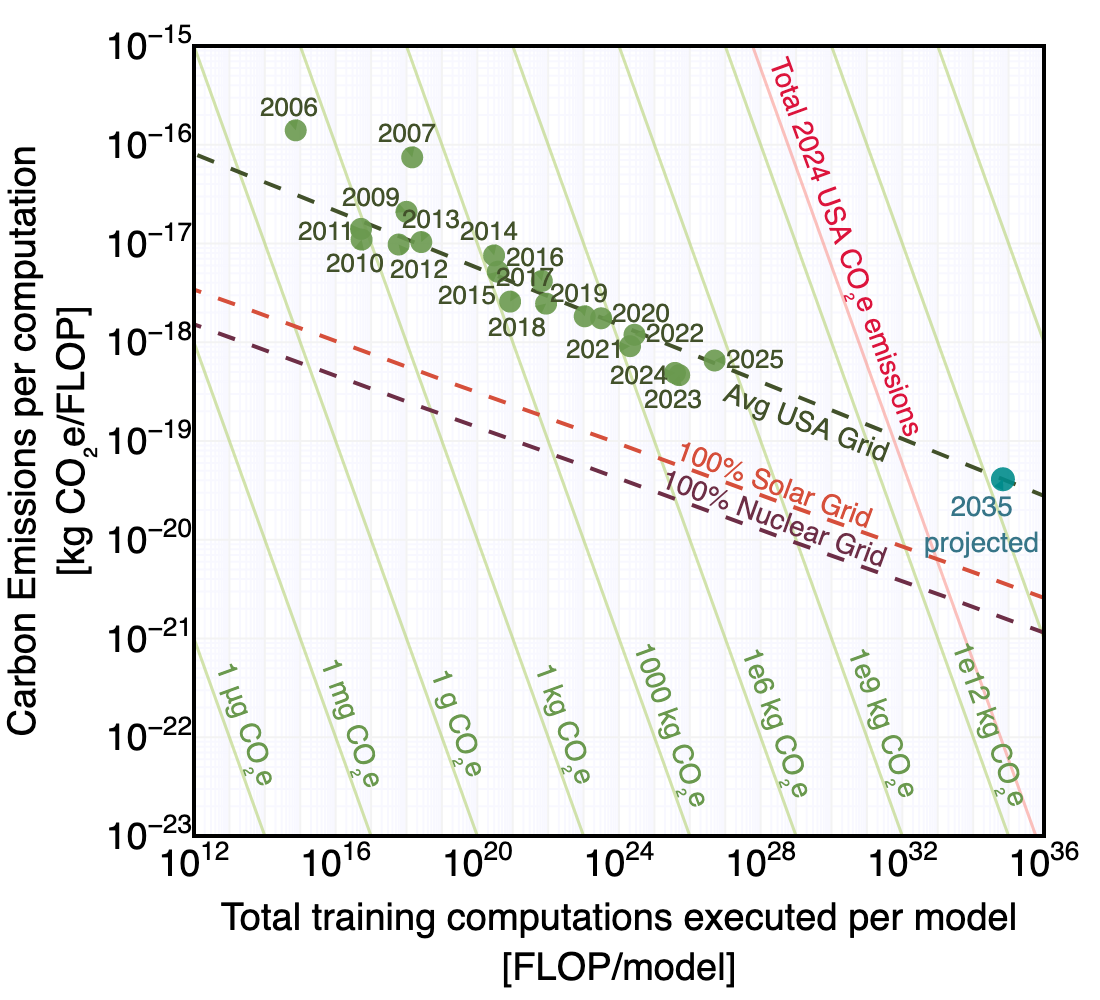

In [26]:
x_axis = 'Training compute (FLOP)'
y_axis = 'Carbon Efficiency [kg CO2e/FLOP]'

nuclear = 'Nuclear Carbon Efficiency [kg CO2e/FLOP]'
solar = 'Solar Carbon Efficiency [kg CO2e/FLOP]'

data = carbonDiffEnergySources_AI.reset_index()

projected_FLOP = next_FLOP
projected_CarbonperFLOP = 0
projected_year = next_year

fig = go.Figure()

minx,maxx= 12, 36
miny,maxy = -23,-15

ai_models__carbon__fitline_dict = {}

#########################################################################################################################

faint_gray = "#F3F3F3" 
fainter_gray = '#F8F8FF'

def add_major_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color=faint_gray, y_color=faint_gray, width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        val = 10 ** exp
        xlines.append(go.Scatter(
            x=[val, val],
            y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
            mode='lines',
            line=dict(color=x_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        val = 10 ** exp
        ylines.append(go.Scatter(
            x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
            y=[val, val],
            mode='lines',
            line=dict(color=y_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

def add_minor_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color=fainter_gray, y_color=fainter_gray, width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            xlines.append(go.Scatter(
                x=[val, val],
                y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
                mode='lines',
                line=dict(color=x_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            ylines.append(go.Scatter(
                x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
                y=[val, val],
                mode='lines',
                line=dict(color=y_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

add_minor_log_gridlines(fig)
add_major_log_gridlines(fig)

#########################################################################################################################
## Trendline for unit elastic demand 

def generate_datapoints(x, y, val, n=10, ypoints_annotate=0):
    xpoints = []
    ypoints = []
    for i in range(1, 4 * n + 1):
        xpoints.append(x * (2 ** i))
        ypoints.append(y / (2 ** i))
    for i in range(1, n + 1):
        xpoints.append(x / (2 ** i))
        ypoints.append(y * (2 ** i))

    log_xpoints = np.log(xpoints)
    log_ypoints = np.log(ypoints)

    slope_points, intercept_points, r_value_points, p_value_points, std_err_points = linregress(log_xpoints, log_ypoints)

    xpoints_annotate = val/ypoints_annotate

    return xpoints, ypoints, xpoints_annotate, ypoints_annotate

co2vals = []
for i in range(-9, 22, 3):   ## powers of e for kgCO2e/model
    co2vals.append(10**i)

co2vals.append(total_USA_CO2emissions)

linecolorval = '#a7c957'
textcolorval = '#6A994E'  
yannotate = 15e-23
opacity=0.5
for val in co2vals:
    if val == total_USA_CO2emissions:
        linecolorval = '#F88379'
        textcolorval = '#DC143C'
        textval = f"Total {total_USA_CO2emissions_year} USA CO₂e emissions" 
        yannotate = 10e-18
        opacity=0.5
        xoffset=0.6
        yoffset=-0.05
    else:
        textval = f"{mass_unit_map_AI[val]} CO₂e"
        xoffset=0.6
        yoffset=-0.05

    
    x, y2, xpoints_annotate, ypoints_annotate = generate_datapoints(1e1, val/1e1, val, n=40, ypoints_annotate = yannotate)
    fig.add_trace(go.Scatter(
        x=x,
        y=y2,
        mode='lines',
        line=dict(color=linecolorval, dash='solid', width=1.5),
        name=f'Trendline {val}',
        yaxis = "y1",
        opacity=opacity
    ))
    fig.add_annotation(
        x=np.log10(xpoints_annotate)+xoffset,
        y=np.log10(ypoints_annotate)+yoffset,
        text=f"{textval}",
        font=dict(size=14, color=textcolorval),
        showarrow=False,
        textangle=70
    )

    


#########################################################################################################################
### Fitted Equation Line for Total Energy Usage

def fitline(x_axis, y_axis, data, projected_FLOP=0, energy_source='USA Grid'):
    global projected_CarbonperFLOP
    log_x = np.log(data[x_axis])
    log_y = np.log(data[y_axis])

    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

    print(f"{energy_source} --- Fitted equation: log(y) = {slope:.4f} log(x) + {intercept:.4f}")
    fitline_dict = {'slope': slope, 'intercept': intercept, 'fitline': f'log(y) = {slope:.4f} log(x) + {intercept:.4f}',
                          'r_value': r_value, 'p_value': p_value, 'std_err': std_err}

    x_fit = np.linspace((2**102)*min(data[x_axis]), max(data[y_axis]), 100)
    y_fit = np.exp(intercept) * x_fit**(slope)  

    x_annotate = 25e28
    y_annotate = np.exp(intercept) * x_annotate**(slope) 

    if projected_FLOP!=0:
        projected_CarbonperFLOP = np.exp(intercept) * projected_FLOP**(slope) 

    return x_fit, y_fit, x_annotate, y_annotate, fitline_dict

x_fit, y_fit, x_annotate, y_annotate, ai_models__carbon__fitline_dict['USA Grid'] = fitline(x_axis, y_axis, data, projected_FLOP, 'USA Grid')
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color='#42512a', dash='dash'),
    name='Fitline USA Grid',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-0.1,
    y=np.log10(y_annotate)-0.2,
    text="Avg USA Grid",
    font=dict(size=14, color='#42512a'),
    showarrow=False,
    textangle=21,
)
fig.add_trace(go.Scatter(
    x=[projected_FLOP],
    y=[projected_CarbonperFLOP],
    mode='markers',
    marker=dict(color='#008B8B', size=12, opacity=0.9), 
    name='2033 Projection',
    yaxis = "y1" 
))


x_fit, y_fit, x_annotate, y_annotate, ai_models__carbon__fitline_dict['Solar'] = fitline(x_axis, solar, data, 0, 'Solar')
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color=colors_dict['Solar'], dash='dash'),
    name='Fitline Solar',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-1,
    y=np.log10(y_annotate)+0.3,
    text="100% Solar Grid",
    font=dict(size=14, color=colors_dict['Solar']),
    showarrow=False,
    textangle=20,
)

x_fit, y_fit, x_annotate, y_annotate, ai_models__carbon__fitline_dict['Nuclear'] = fitline(x_axis, nuclear, data, 0, 'Nuclear')
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color=colors_dict['Nuclear'], dash='dash'),
    name='Fitline Nuclear',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-1,
    y=np.log10(y_annotate)+0.3,
    text="100% Nuclear Grid",
    font=dict(size=14, color=colors_dict['Nuclear']),
    showarrow=False,
    textangle=20,
)

#########################################################################################################################
### Datapoints for (year,power/hashrate)

fig.add_trace(go.Scatter(
    x=data[x_axis],
    y=data[y_axis],
    mode='markers',
    marker=dict(color='#6a994e', size=11, opacity=0.9), 
    name='USA Grid Carbon',
    yaxis = "y1" 
))


#########################################################################################################################
## Annotations

for i in range(len(data)):
    
    up = [2006, 2014, 2016, 2007, 2008, 2019]
    down = [2023,  2010] #, 2019] 2021,

    arx, ary = 0, 0
    if int(data['Model Year'][i]) in up:
        arx, ary = -3,-12
    if int(data['Model Year'][i]) in down:
        arx, ary = -3,12
    if int(data['Model Year'][i]) in [2009]:
        arx, ary = -18,-7
    if int(data['Model Year'][i]) in [2011, 2021, 2024]:
        arx, ary = -18, 1 #5, -10
    if int(data['Model Year'][i]) in [2012]:
        arx, ary = 10,12
    if int(data['Model Year'][i]) in [2013]:
        arx, ary = 5,-12
    if int(data['Model Year'][i]) in [2017]:
        arx, ary = 7,-12
    if int(data['Model Year'][i]) in [2020]:
        arx, ary = 20, -3
    if int(data['Model Year'][i]) in [2022, 2025]:
        arx, ary = 20, -1
    if int(data['Model Year'][i]) in [2015, 2018]:
        arx, ary = -15,12

    fig.add_annotation(
        x=np.log10(data[x_axis][i]),
        y=np.log10(data[y_axis][i]),
        text=str(data['Model Year'][i]),
        showarrow=True,
        arrowhead=2,
        ax=arx,
        ay=ary,
        font=dict(size=13, color='#42512a'),
        arrowcolor='#6a994e',
    )

arx, ary = -10, 22
fig.add_annotation(
    x=np.log10(projected_FLOP),
    y=np.log10(projected_CarbonperFLOP),
    text=f"{str(projected_year)}<br>projected",
    showarrow=True,
    arrowhead=2,
    ax=arx,
    ay=ary,
    font=dict(size=14, color='#367588'),
    arrowcolor='#008B8B',
)


#########################################################################################################################
## Graph Layout

fig.update_layout(
    width=550,  
    height=500,
    xaxis=dict(
        type='log',
        exponentformat="power",
        showexponent="all",
        title=dict(
            text=  'Total training computations executed per model<br>[FLOP/model]',
            standoff=10,
            font=dict(size=19)),
        
        range=[minx,maxx], 
        showgrid=False,
        gridcolor='lightgray',  
        zeroline=False,
        tickfont=dict(size=15)
    ),
    yaxis=dict(
        type='log',
        # dtick=1,
        exponentformat="power",
        showexponent="all",
        side="left",
        title=dict(
            text=  'Carbon Emissions per computation<br>[kg CO₂e/FLOP]',  
            standoff=5,
            font=dict(size=19)), 
        range=[miny,maxy],
        showgrid=False,
        gridcolor='lightgray', 
        zeroline=False,
        tickfont=dict(size=15)
    ),
    font=dict(family='Helvetica', size=12, color='black'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=10, r=10, t=10, b=10),
    
    shapes=[dict(
        type='rect',
        x0=0, x1=1, y0=0, y1=1,
        xref='paper', yref='paper',
        line=dict(color='black', width=2)
    )]
)

filename = "graphs/ai__carbon_footprint"
fig.write_image(f"{filename}.pdf", scale=2)
fig.write_image(f"{filename}.png", scale=2)

display(Image(filename=f"{filename}.png"))

In [27]:
### Elasticity of Computational Demand for Carbon Footprint
elasticity_carbon = 1/ai_models__carbon__fitline_dict['USA Grid']['slope']
print(f"Elasticity of Computational Demand for Carbon Footprint: {abs(elasticity_carbon):.4f}")

Elasticity of Computational Demand for Carbon Footprint: 6.9297


In [28]:
### Calculating Total Carbon Emissions for 2033 based on the linear regression fit line

projected_totalcarbon = projected_CarbonperFLOP * projected_FLOP
totalcarbon_2025 = projectioncarbon_AI[projectioncarbon_AI['Model Year']==2025]['Carbon/model [kg CO2e]'].values[0]
print(f"{next_year} Total Carbon (kgCO2ee): {projected_totalcarbon:0.2e}")
print(f"{last_year} Total Carbon (kgCO2ee): {totalcarbon_2025:0.2e}")
print(f"Ratio of Projected Total Carbon Emissions in {next_year} to {last_year}: {projected_totalcarbon/totalcarbon_2025:0.2e}")

2035 Total Carbon (kgCO2ee): 2.84e+15
2025 Total Carbon (kgCO2ee): 3.27e+08
Ratio of Projected Total Carbon Emissions in 2035 to 2025: 8.69e+06


In [29]:
### Calculates the number of years required to transition the USA grid to fully nuclear energy
### while maintaining constant total carbon emissions. The calculation starts from the year 2025
### and assumes a median year-on-year improvement in the projected carbon intensity of the USA grid.


USAaverageCI_2025 = analysecarbonintensity_AI[analysecarbonintensity_AI['Model Year'] == 2025]['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]'].values[0]  # 369.47318 gCO2e/kWh
NuclearmedianCI = energysourcescarbonintensity[energysourcescarbonintensity['Source'] == 'Nuclear']['Median Carbon Intensity [kg CO2e/J]'].values[0]  # 12 gCO2e/kWh
ratio = USAaverageCI_2025 / NuclearmedianCI

count = 0
change = USAaverageCI_2025

while change > NuclearmedianCI:
    change = change * (1 + median_yoychange_projectedcarbonintensity) ## median year-on-year change in projected carbon intensity is 80%
    count += 1

print(f"To keep total carbon emissions constant, the USA grid would need to completely transition to nuclear within {count - 1} years.")


### Calculate the number of years required for total carbon emissions to exceed the last known value
### assuming a median year-on-year change in FLOP

def usagridfitline(FLOP):
    slope, intercept = -0.1525, -16.8134
    energyperFLOP = np.exp(intercept) * (FLOP ** slope)
    carbonperFLOP = energyperFLOP * (USAaverageCI_2025 * (1 + median_yoychange_projectedcarbonintensity))
    totalCarbon = carbonperFLOP * FLOP
    return totalCarbon

print(f"Median year-on-year change in FLOP: {median_yoyFLOP:.2%}")

last_FLOP = carbonDiffEnergySources_AI.loc[carbonDiffEnergySources_AI['Model Year'] == last_year, 'Training compute (FLOP)'].values[0]
last_CarbonperFLOP = carbonDiffEnergySources_AI.loc[carbonDiffEnergySources_AI['Model Year'] == last_year, 'Carbon Efficiency [kg CO2e/FLOP]'].values[0]
last_totalCarbon = last_FLOP * last_CarbonperFLOP

next_totalCarbon = 0
count = 0
while next_totalCarbon < last_totalCarbon:
    next_FLOP = last_FLOP * ((1 + median_yoyFLOP))
    next_totalCarbon = usagridfitline(next_FLOP)
    last_FLOP = next_FLOP
    count += 1

print(f"Considering median change in FLOP and Energy/FLOP, the total carbon emissions will exceed the last known value in {count - 1} years.")

To keep total carbon emissions constant, the USA grid would need to completely transition to nuclear within 2 years.
Median year-on-year change in FLOP: 551.91%
Considering median change in FLOP and Energy/FLOP, the total carbon emissions will exceed the last known value in 1 years.


---

## Bitcoin Mining

### Mining ASICs
- ASIC data from Accelerator Wall paper: https://github.com/PrincetonUniversity/accelerator-wall/tree/master/accelerator-zoo/asic-bitcoin-miners
- ASICMinerValue: https://www.asicminervalue.com/efficiency

In [30]:
### ASIC Miner Mining Hardware

asicminerdata = pd.read_csv('data/asic_miner_ASIC_hardware.csv')
def convert_value(value):
    if 'Th/s' in value:
        return float(value.split()[0])   
    elif 'Gh/s' in value:
        return float(value.split()[0]) / 1000
    if 'j/Th' in value:
        return float(value[:-4].split()[0])   
    elif 'j/Gh' in value:
        return float(value[:-4].split()[0]) * 1000

asicminerdata['Hashrate[TH/s]'] = asicminerdata['Hashrate'].apply(convert_value)
asicminerdata['Energy Efficiency[J/TH]'] = asicminerdata['Efficiency'].apply(convert_value)

asicminerdata['Year'] = asicminerdata['Release'].str.extract(r'(\d+)').astype(int)
asicminerdata['Power[W]'] = asicminerdata['Power'].str.extract(r'(\d+)').astype(float)
asicminerdata['Power/Hashrate [J/TH]'] = asicminerdata['Power[W]']/asicminerdata['Hashrate[TH/s]']

asicminerdata_cleaned = asicminerdata[['Manufacturer', 'Model', 'Year', 'Profit', 'Hashrate[TH/s]', 'Power[W]', 'Energy Efficiency[J/TH]', 'Power/Hashrate [J/TH]']]

In [31]:
### Mining ASIC Hardware Data from Acclerator Wall Paper

acceleratorwallasicdata= pd.read_csv('data/AcceleratorWall_ASIC_hardware.csv')
acceleratorwallasicdata['Power/Hashrate [J/TH]'] = (10**6)/acceleratorwallasicdata['Energy Efficiency[MH/J]']
acceleratorwallasicdata['Hashrate[TH/s]'] = acceleratorwallasicdata['Throughput [Mhash/s]']/(10**6)

acceleratorwallasicdata.rename(columns={'Introduction Year': 'Year', 'Name': 'Model'}, inplace=True)
acceleratorwallasicdata_cleaned = acceleratorwallasicdata[['Model', 'Year', 'Hashrate[TH/s]', 'Power/Hashrate [J/TH]']]


In [32]:
### Merging ASIC Miner Data and Accelerator Wall Data

asicdata = merge_dfs([asicminerdata_cleaned, acceleratorwallasicdata_cleaned],'Model','outer')

columns = ['Hashrate[TH/s]', 'Year', 'Power/Hashrate [J/TH]']
for column in columns: 
    asicdata[column] = asicdata[[column+'_x', column+'_y']].apply(lambda x: str(x[column+'_x']) if pd.notna(x[column+'_x']) else str(x[column+'_y']), axis=1)
    asicdata = asicdata.drop(columns=[column+'_x', column+'_y'])

asicdata['Year'] = asicdata['Year'].astype(float).astype(int)
asicdata['Hashrate[TH/s]'] = asicdata['Hashrate[TH/s]'].astype(float)
asicdata['Power/Hashrate [J/TH]'] = asicdata['Power/Hashrate [J/TH]'].astype(float)

bestasic = asicdata.loc[asicdata.groupby('Year')['Hashrate[TH/s]'].idxmax()]
bestasic.rename(columns={'Year': 'ASIC Release Year'}, inplace=True)
bestasic['Year'] = bestasic['ASIC Release Year'] + 1

### Bitcoin Hashrate
- Hashrate data from Blockchain.com: https://www.blockchain.com/explorer/charts/hash-rate


In [35]:
hashratedata = pd.read_csv('data/bitcoin-hashrate.csv')
hashratedata['Year'] = hashratedata['hashrate-datetime'].str[:4]

hashratedata_cleaned = hashratedata[['hashrate[TH/s]', 'price[USD]', 'Year']]

average_hashrate = hashratedata_cleaned.groupby('Year')['hashrate[TH/s]'].mean().reset_index()
total_seconds_per_year = 60*60*24*365
average_hashrate['Terahashes per year[TH/year]'] = average_hashrate['hashrate[TH/s]'] * total_seconds_per_year
average_hashrate['Year'] = average_hashrate['Year'].astype(int)

average_hashrate.rename(columns={'hashrate[TH/s]': 'average hashrate[TH/s] in an year'}, inplace=True)


### Combining ASIC hardware and Hashrate data
- considering all the hashes from a given year run on the best ASIC hardware from the previous year

In [36]:
data_asic_averagehashrate = merge_dfs([bestasic, average_hashrate],'Year','inner')


In [37]:
### Calculating the Terahashes per year[TH/year] for 2035 based on median Year on Year Change in Terahashes per year[TH/year].
### This is done by calculating the median Year on Year Change in Terahashes per year[TH/year] from Model Years 2006 to 2025 
### and then applying that change to the last known value in 2025 to estimate the value for 2035.

col = 'Terahashes per year[TH/year]'
last_year, next_year = 2025, 2035

sliced_data_asic_averagehashrate = data_asic_averagehashrate[data_asic_averagehashrate['Year'] <= last_year].copy()
sliced_data_asic_averagehashrate[f'yoy_change {col}'] = sliced_data_asic_averagehashrate[col].pct_change()
median_yoyTH = sliced_data_asic_averagehashrate[f'yoy_change {col}'].median()

print(f"Median Year on Year Change in Terahashes per year[TH/year]: {median_yoyTH:.2%}")

last_TH = sliced_data_asic_averagehashrate.loc[sliced_data_asic_averagehashrate['Year'] == last_year, 'Terahashes per year[TH/year]'].values[0]
next_TH = last_TH * ((1 + median_yoyTH)**(next_year-last_year))

print(f"({last_year}) Training Compute (FLOP): {last_TH:.2e}")
print(f"({next_year}) Training Compute (FLOP): {next_TH:.2e}")


Median Year on Year Change in Terahashes per year[TH/year]: 82.78%
(2025) Training Compute (FLOP): 2.89e+16
(2035) Training Compute (FLOP): 1.20e+19


## Energy Consumption

In [38]:
totalenergy_BM = copy.deepcopy(data_asic_averagehashrate)
totalenergy_BM['Energy/yearly_TH [J]'] = totalenergy_BM['Power/Hashrate [J/TH]']*totalenergy_BM['Terahashes per year[TH/year]']

Fitted equation: log(y) = -0.4536 log(x) + 19.9940


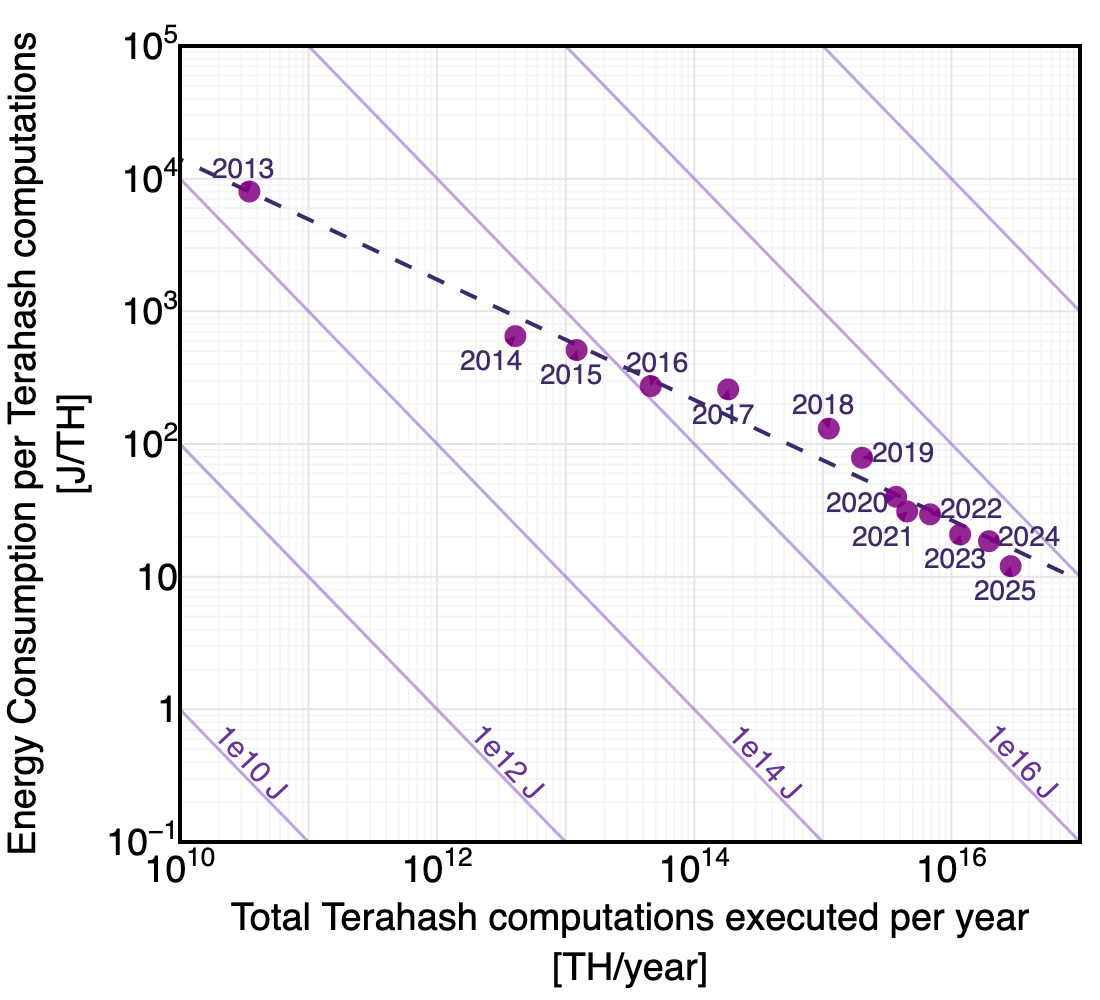

In [ ]:
data = totalenergy_BM[(totalenergy_BM['Year']>2011) & (totalenergy_BM['Year']<2026)].reset_index()

x_axis = 'Terahashes per year[TH/year]'
y_axis = 'Power/Hashrate [J/TH]'

fig = go.Figure()


minx,maxx= 10,17 
miny,maxy = -1, 5

#########################################################################################################################

def add_major_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color="#E5E5E5", y_color="#E5E5E5", width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        val = 10 ** exp
        xlines.append(go.Scatter(
            x=[val, val],
            y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
            mode='lines',
            line=dict(color=x_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        val = 10 ** exp
        ylines.append(go.Scatter(
            x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
            y=[val, val],
            mode='lines',
            line=dict(color=y_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

def add_minor_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color="#F5F5F5", y_color="#F5F5F5", width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            xlines.append(go.Scatter(
                x=[val, val],
                y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
                mode='lines',
                line=dict(color=x_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            ylines.append(go.Scatter(
                x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
                y=[val, val],
                mode='lines',
                line=dict(color=y_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

add_minor_log_gridlines(fig)
add_major_log_gridlines(fig)

#########################################################################################################################

def generate_datapoints(x, y, val, n=10):
    xpoints = []
    ypoints = []
    for i in range(1, 4 * n + 1):
        xpoints.append(x * (2 ** i))
        ypoints.append(y / (2 ** i))
    for i in range(1, n + 1):
        xpoints.append(x / (2 ** i))
        ypoints.append(y * (2 ** i))

    log_xpoints = np.log(xpoints)
    log_ypoints = np.log(ypoints)

    slope_points, intercept_points, r_value_points, p_value_points, std_err_points = linregress(log_xpoints, log_ypoints)

    ypoints_annotate = 0.4
    xpoints_annotate = val/ypoints_annotate

    return xpoints, ypoints, xpoints_annotate, ypoints_annotate

energyvals = []
for i in range(10, 21, 2):   ## powers of e for kgCO2e/model
    energyvals.append(10**i)

for val in energyvals:
    x, y2, xpoints_annotate, ypoints_annotate = generate_datapoints(1e1, val/1e1, val, n=40)
    fig.add_trace(go.Scatter(
        x=x,
        y=y2,
        mode='lines',
        line=dict(color='#9966cc', dash='solid', width=1.5),
        name=f'Trendline {val}',
        yaxis = "y1",
        opacity=0.6
    ))
    fig.add_annotation(
        x=np.log10(xpoints_annotate)+0.15,
        y=np.log10(ypoints_annotate),
        text=f"{energy_unit_map_BM[val]}",
        font=dict(size=15, color='#663399'),
        showarrow=False,
        textangle=47,
    )


#########################################################################################################################

log_x = np.log(data[x_axis])
log_y = np.log(data[y_axis])

slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

print(f"Fitted equation: log(y) = {slope:.4f} log(x) + {intercept:.4f}")
bitcoin_mining__energy__fitline_dict = {'slope': slope, 'intercept': intercept, 'fitline': f'log(y) = {slope:.4f} log(x) + {intercept:.4f}',
                            'r_value': r_value, 'p_value': p_value, 'std_err': std_err}

x_fit = np.linspace((2**64)*min(data[x_axis]), max(data[y_axis]), 100)
y_fit = np.exp(intercept) * x_fit**(slope)  

fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color='#3f2a69', dash='dash'),
    name='Fitline'
))


#########################################################################################################################


fig.add_trace(go.Scatter(
    x=data[x_axis],
    y=data[y_axis],
    mode='markers',
    marker=dict(color='purple', size=11, opacity=0.85),
    name='Data Points'
))

#########################################################################################################################


for i in range(len(data)):

    up = [2013, 2018]
    down= [ 2015,  2017, 2023, 2025]
    downleft = [2014, 2021]
    right = [2019, 2022, 2024]

    arx, ary = 0, 0
    if int(data['Year'][i]) in up:
        arx, ary = -3,-12
    if int(data['Year'][i]) in down:
        arx, ary = -3,12
    if int(data['Year'][i]) in downleft:
        arx, ary = -12,12
    if int(data['Year'][i]) in right:
        arx, ary = 20, -3 #5, -10
    if int(data['Year'][i]) in [2020]:
        arx, ary = -20, 3 #5, -10
    if int(data['Year'][i]) in [2016]:
        arx, ary = 3,-12

    fig.add_annotation(
        x=np.log10(data[x_axis][i]),
        y=np.log10(data[y_axis][i]),
        text=str(data['Year'][i]),
        showarrow=True,
        arrowhead=2,
        ax=arx,
        ay=ary,
        font=dict(size=14, color='#3f2a69'),
        arrowcolor='purple'
    )


#########################################################################################################################


fig.update_layout(
    width=550,  
    height=500,
    xaxis=dict(
        type='log',
        exponentformat="power",
        showexponent="all",
        title=dict(
            text= 'Total Terahash computations executed per year<br>[TH/year]',
            standoff=7,
            font=dict(size=19)),
        range=[minx,maxx],
        showgrid=False,
        gridcolor='lightgray',  
        zeroline=False,
        tickfont=dict(size=15)
    ),
    yaxis=dict(
        type='log',
        dtick=1,
        exponentformat="power",
        showexponent="all",
        title=dict(
            text=  'Energy Consumption per Terahash computations<br>[J/TH]',
            standoff=5,
            font=dict(size=19)),
        range=[miny,maxy], 
        showgrid=False,
        gridcolor='lightgray', 
        zeroline=False,
        tickfont=dict(size=15)
    ),
    font=dict(family='Helvetica', size=10, color='black'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=10, r=10, t=10, b=10),
    
    shapes=[dict(
        type='rect',
        x0=0, x1=1, y0=0, y1=1,
        xref='paper', yref='paper',
        line=dict(color='black', width=2)
    )]
)

filename = "graphs/bitcoin_mining__energy_consumption"
fig.write_image(f"{filename}.png", scale=2)
fig.write_image(f"{filename}.pdf", scale=2)

display(Image(filename=f"{filename}.png"))


In [40]:
### Elasticity of Computational Demand for Energy Consumption
elasticity_energy = 1/bitcoin_mining__energy__fitline_dict['slope']
print(f"Elasticity of Computational Demand for Energy Consumption: {abs(elasticity_energy):.4f}")

Elasticity of Computational Demand for Energy Consumption: 2.2044


## Carbon Footprint

In [41]:
### Total Carbon Emissions Calculation for the best model in the current year running on the best hardware from the previous years

carbonintensity_USA.index.name = 'Year'
totalcarbon_BM = merge_dfs([totalenergy_BM, carbonintensity_USA], 'Year', 'inner')
totalcarbon_BM['Carbon Efficiency [kg CO2e/TH]'] = totalcarbon_BM['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']*totalcarbon_BM['Power/Hashrate [J/TH]']
totalcarbon_BM['Carbon/yearly_TH [kg CO2e]'] = totalcarbon_BM['Carbon Efficiency [kg CO2e/TH]']*totalcarbon_BM['Terahashes per year[TH/year]']

    

In [42]:
### Projecting improvements needed in carbon intensity and carbon efficiency 
### if we want to keep the total carbon emissions constant, equivalent to the total carbon emissions in 2006

cuttoffYear = 2013
def projection_BM(totalcarbon, cuttoffYear):
    idealtotalcarbon = totalcarbon[totalcarbon['Year']==cuttoffYear]['Carbon/yearly_TH [kg CO2e]'].values[0]
    
    projectioncarbon = copy.deepcopy(totalcarbon)
    projectioncarbon = projectioncarbon[projectioncarbon['Year']>=cuttoffYear]
    projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'] = idealtotalcarbon/projectioncarbon['Energy/yearly_TH [J]']
    projectioncarbon['Projected Carbon Efficiency [kg CO2e/TH]'] = projectioncarbon['Power/Hashrate [J/TH]']*projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']
    projectioncarbon['Ratio in Carbon Intensity of USA Grid to Projected'] = projectioncarbon['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']/(projectioncarbon['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'])
    return projectioncarbon


projectioncarbon_BM = projection_BM(totalcarbon_BM, cuttoffYear)

In [43]:
### Required annual improvement in carbon intensity of the electricity grid to keep total carbon emissions constant

analysecarbonintensity_BM = projectioncarbon_BM[['ASIC Release Year', 'Year', 'USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]','Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']].copy()
analysecarbonintensity_BM['USA Average Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_BM['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]']*factor_KGperJ_to_GperKWH
analysecarbonintensity_BM['Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_BM['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]']*factor_KGperJ_to_GperKWH

analysecarbonintensity_BM['yoy_change Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'] = analysecarbonintensity_BM['Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'].pct_change()
analysecarbonintensity_BM['yoy_change Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'] = analysecarbonintensity_BM['Projected Carbon Intensity of Electricity Grid [kg CO2e/J]'].pct_change()

median_yoychange_projectedcarbonintensity = analysecarbonintensity_BM['yoy_change Projected Carbon Intensity of Electricity Grid [g CO2e/kWh]'].median()
print(f"Median Year on Year Change in Projected Carbon Intensity of Electricity Grid: {median_yoychange_projectedcarbonintensity:.2%}")



Median Year on Year Change in Projected Carbon Intensity of Electricity Grid: -31.62%


In [44]:
### Carbon efficiency of different energy sources 

carbonDiffEnergySources_BM = copy.deepcopy(totalcarbon_BM)
for i, source in enumerate(list(energysourcescarbonintensity['Source'])):
    ci_source = energysourcescarbonintensity[energysourcescarbonintensity['Source']==source]['Median Carbon Intensity [kg CO2e/J]'].values[0]
    carbonDiffEnergySources_BM[f'{source} Carbon Efficiency [kg CO2e/TH]'] = carbonDiffEnergySources_BM['Power/Hashrate [J/TH]']*ci_source


USA Grid --- Fitted equation: log(y) = -0.4810 log(x) + 5.0100
Solar --- Fitted equation: log(y) = -0.4536 log(x) + 1.2856
Nuclear --- Fitted equation: log(y) = -0.4536 log(x) + 0.4747


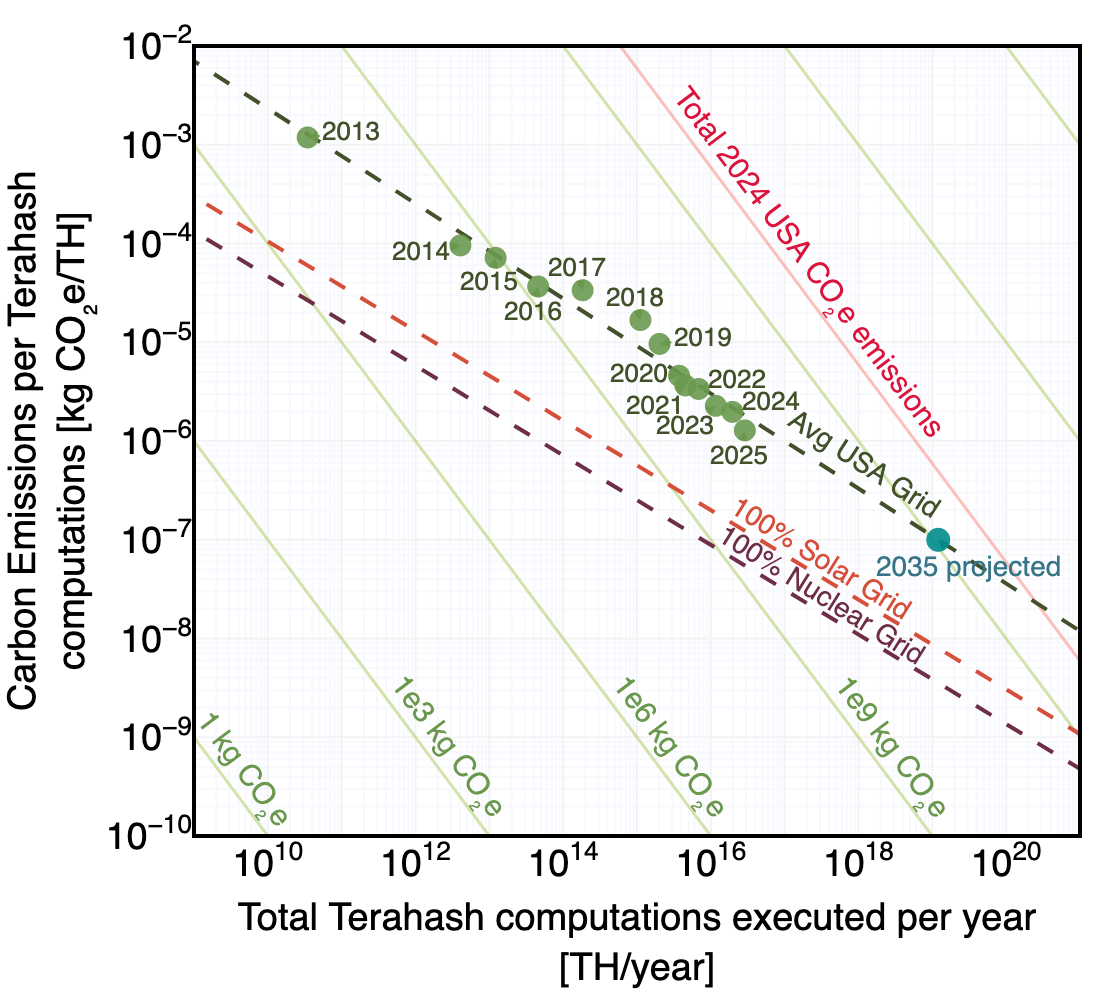

In [45]:
x_axis = 'Terahashes per year[TH/year]'
y_axis = 'Carbon Efficiency [kg CO2e/TH]'
data = carbonDiffEnergySources_BM[(carbonDiffEnergySources_BM['Year']>2011) & (carbonDiffEnergySources_BM['Year']<2024)].reset_index()
data = carbonDiffEnergySources_BM.reset_index()

nuclear = 'Nuclear Carbon Efficiency [kg CO2e/TH]'
solar = 'Solar Carbon Efficiency [kg CO2e/TH]'



projected_TH = next_TH
projected_CarbonperTH = 0
projected_year = next_year

fig = go.Figure()

minx,maxx= 9,21
miny,maxy = -10,-2

bitcoin_mining__carbon__fitline_dict = {}

#########################################################################################################################

faint_gray = "#F3F3F3" 
fainter_gray = '#F8F8FF'

def add_major_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color=faint_gray, y_color=faint_gray, width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        val = 10 ** exp
        xlines.append(go.Scatter(
            x=[val, val],
            y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
            mode='lines',
            line=dict(color=x_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        val = 10 ** exp
        ylines.append(go.Scatter(
            x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
            y=[val, val],
            mode='lines',
            line=dict(color=y_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

def add_minor_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color=fainter_gray, y_color=fainter_gray, width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            xlines.append(go.Scatter(
                x=[val, val],
                y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
                mode='lines',
                line=dict(color=x_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        for m in range(2, 10):
            val = m * 10 ** exp
            ylines.append(go.Scatter(
                x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
                y=[val, val],
                mode='lines',
                line=dict(color=y_color, width=width),
                hoverinfo='skip',
                showlegend=False
            ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

add_minor_log_gridlines(fig)
add_major_log_gridlines(fig)


#########################################################################################################################


def generate_datapoints(x, y, val, n=10, ypoints_annotate=0):
    xpoints = []
    ypoints = []
    for i in range(1, 4 * n + 1):
        xpoints.append(x * (2 ** i))
        ypoints.append(y / (2 ** i))
    for i in range(1, n + 1):
        xpoints.append(x / (2 ** i))
        ypoints.append(y * (2 ** i))

    log_xpoints = np.log(xpoints)
    log_ypoints = np.log(ypoints)

    slope_points, intercept_points, r_value_points, p_value_points, std_err_points = linregress(log_xpoints, log_ypoints)

    xpoints_annotate = val/ypoints_annotate

    return xpoints, ypoints, xpoints_annotate, ypoints_annotate

co2vals = []
for i in range(-9, 22, 3):   ## powers of e for kgCO2e/model
    co2vals.append(10**i)

co2vals.append(total_USA_CO2emissions)

linecolorval = '#a7c957'
textcolorval = '#6A994E'
yannotate = 0.8*1e-9
opacity=0.5
# textval = mass_unit_map[]
for val in co2vals:
    if val == total_USA_CO2emissions:
        linecolorval = '#F88379'
        textcolorval = '#DC143C'
        textval = f"Total {total_USA_CO2emissions_year} USA CO₂e emissions"
        yannotate = 10e-5
        opacity=0.5
        xoffset=0.55
        yoffset=-0.2
    else:
        textval = f"{mass_unit_map_BM[val]} CO₂e"
        xoffset=0.35
        yoffset=0
        if val==1:
            xoffset=0.57
            yoffset=-0.23

    
    x, y2, xpoints_annotate, ypoints_annotate = generate_datapoints(1e1, val/1e1, val, n=40, ypoints_annotate = yannotate)
    fig.add_trace(go.Scatter(
        x=x,
        y=y2,
        mode='lines',
        line=dict(color=linecolorval, dash='solid', width=1.5),
        name=f'Trendline {val}',
        yaxis = "y1",
        opacity=opacity
    ))
    fig.add_annotation(
        x=np.log10(xpoints_annotate)+xoffset,
        y=np.log10(ypoints_annotate)+yoffset,
        text=f"{textval}",
        font=dict(size=15, color=textcolorval),
        showarrow=False,
        textangle=53,
    )  

#########################################################################################################################
### Fitted Equation Line for Total Energy Usage

def fitline(x_axis, y_axis, data, projected_TH=0, energy_source='USA Grid'):
    global projected_CarbonperTH
    log_x = np.log(data[x_axis])
    log_y = np.log(data[y_axis])

    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

    print(f"{energy_source} --- Fitted equation: log(y) = {slope:.4f} log(x) + {intercept:.4f}")
    fitline_dict = {'slope': slope, 'intercept': intercept, 'fitline': f'log(y) = {slope:.4f} log(x) + {intercept:.4f}',
                    'r_value': r_value, 'p_value': p_value, 'std_err': std_err}

    x_fit = np.linspace((2**100)*min(data[x_axis]), max(data[y_axis]), 100)
    y_fit = np.exp(intercept) * x_fit**(slope)  

    x_annotate = 0.2*10e18
    y_annotate = np.exp(intercept) * x_annotate**(slope) 

    if projected_TH!=0:
        projected_CarbonperTH = np.exp(intercept) * projected_TH**(slope) 

    return x_fit, y_fit, x_annotate, y_annotate, fitline_dict

x_fit, y_fit, x_annotate, y_annotate, bitcoin_mining__carbon__fitline_dict['USA Grid'] = fitline(x_axis, y_axis, data, projected_TH, 'USA Grid')
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color='#42512a', dash='dash'),
    name='Fitline USA Grid',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-0.2,
    y=np.log10(y_annotate)+0.4,
    text="Avg USA Grid",
    font=dict(size=14, color='#42512a'),
    showarrow=False,
    textangle=33,
)
fig.add_trace(go.Scatter(
    x=[projected_TH],
    y=[projected_CarbonperTH],
    mode='markers',
    marker=dict(color='#008B8B', size=12, opacity=0.9), 
    name='2033 Projection',
    yaxis = "y1" 
))


x_fit, y_fit, x_annotate, y_annotate, bitcoin_mining__carbon__fitline_dict['Solar'] = fitline(x_axis, solar, data, 0, "Solar")
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color=colors_dict['Solar'], dash='dash'),
    name='Fitline Solar',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-0.8,
    y=np.log10(y_annotate)+0.55,
    text="100% Solar Grid",
    font=dict(size=14, color=colors_dict['Solar']),
    showarrow=False,
    textangle=32,
)

x_fit, y_fit, x_annotate, y_annotate, bitcoin_mining__carbon__fitline_dict['Nuclear'] = fitline(x_axis, nuclear, data, 0, "Nuclear")
fig.add_trace(go.Scatter(
    x=x_fit, 
    y=y_fit, 
    mode='lines', 
    line=dict(color=colors_dict['Nuclear'], dash='dash'),
    name='Fitline Nuclear',
    yaxis = "y1" 
))
fig.add_annotation(
    x=np.log10(x_annotate)-0.8,
    y=np.log10(y_annotate)+0.55,
    text="100% Nuclear Grid",
    font=dict(size=14, color=colors_dict['Nuclear']),
    showarrow=False,
    textangle=32,
)

#########################################################################################################################
### Datapoints for (year,power/hashrate)

fig.add_trace(go.Scatter(
    x=data[x_axis],
    y=data[y_axis],
    mode='markers',
    marker=dict(color='#6a994e', size=11, opacity=0.9), 
    name='USA Grid Carbon',
    yaxis = "y1" 
))


#########################################################################################################################
## Annotations

for i in range(len(data)):

    up = [2017, 2018]
    down= [ 2015, 2016, 2023, 2025]
    downleft = [2021, 2023]
    right = [2013, 2019]

    arx, ary = 0, 0
    if int(data['Year'][i]) in up:
        arx, ary = -3,-12
    if int(data['Year'][i]) in down:
        arx, ary = -3,12
    if int(data['Year'][i]) in downleft:
        arx, ary = -15,10
    if int(data['Year'][i]) in right:
        arx, ary = 22, -3
    if int(data['Year'][i]) in [2014]:
        arx, ary = -20, 3 
    if int(data['Year'][i]) in [2020]:
        arx, ary = -20, -1 
    if int(data['Year'][i]) in [2022, 2024]:
        arx, ary = 19, -5 
    
    

    fig.add_annotation(
        x=np.log10(data[x_axis][i]),
        y=np.log10(data[y_axis][i]),
        text=str(data['Year'][i]),
        showarrow=True,
        arrowhead=2,
        ax=arx,
        ay=ary,
        font=dict(size=13, color='#42512a'),
        arrowcolor='#6a994e',
    )

arx, ary = 15, 13
fig.add_annotation(
    x=np.log10(projected_TH),
    y=np.log10(projected_CarbonperTH),
    text=f"{str(projected_year)} projected",
    showarrow=True,
    arrowhead=2,
    ax=arx,
    ay=ary,
    font=dict(size=14, color='#367588'),
    arrowcolor='#008B8B',
)


#########################################################################################################################
## Graph Layout

fig.update_layout(
    width=550,  
    height=500,
    xaxis=dict(
        type='log',
        exponentformat="power",
        showexponent="all",
        title=dict(
            text=  'Total Terahash computations executed per year<br>[TH/year]',
            standoff=10,
            font=dict(size=19)),
        range=[minx,maxx],  
        showgrid=False,
        gridcolor='lightgray',  
        zeroline=False,
        tickfont=dict(size=15)
    ),
    yaxis=dict(
        type='log',
        exponentformat="power",
        showexponent="all",
        side="left",
        title=dict(
            text=  'Carbon Emissions per Terahash<br>computations [kg CO₂e/TH]',  
            standoff=5,
            font=dict(size=19)),  
        range=[miny,maxy],  
        showgrid=False,
        gridcolor='lightgray', 
        zeroline=False,
        tickfont=dict(size=15)
    ),
    font=dict(family='Helvetica', size=12, color='black'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=10, r=10, t=10, b=10),
    
    shapes=[dict(
        type='rect',
        x0=0, x1=1, y0=0, y1=1,
        xref='paper', yref='paper',
        line=dict(color='black', width=2)
    )]
)

filename = "graphs/bitcoin_mining__carbon_footprint"
fig.write_image(f"{filename}.png", scale=2)
fig.write_image(f"{filename}.pdf", scale=2)

display(Image(filename=f"{filename}.png"))

In [46]:
### Elasticity of Computational Demand for Carbon Footprint
elasticity_carbon = 1/bitcoin_mining__carbon__fitline_dict['USA Grid']['slope']
print(f"Elasticity of Computational Demand for Carbon Footprint: {abs(elasticity_carbon):.4f}")

Elasticity of Computational Demand for Carbon Footprint: 2.0792


In [47]:
### Calculating Total Carbon Emissions for 2033 based on the linear regression fit line

projected_totalcarbon = projected_CarbonperTH*projected_TH
totalcarbon_2025 = projectioncarbon_BM[projectioncarbon_BM['Year']==2025]['Carbon/yearly_TH [kg CO2e]'].values[0]
print(f"2033 Total Carbon (kgCO2ee): {projected_totalcarbon:0.2e}")
print(f"2025 Total Carbon (kgCO2ee): {totalcarbon_2025:0.2e}")
print(f"Ratio of Projected Total Carbon Emissions in 2033 to 2025: {projected_totalcarbon/totalcarbon_2025:0.2e}")

2033 Total Carbon (kgCO2ee): 1.20e+12
2025 Total Carbon (kgCO2ee): 3.70e+10
Ratio of Projected Total Carbon Emissions in 2033 to 2025: 3.24e+01


In [48]:
### Calculates the number of years required to transition the USA grid to fully nuclear energy
### while maintaining constant total carbon emissions. The calculation starts from the year 2025
### and assumes a median year-on-year improvement in the projected carbon intensity of the USA grid.


USAaverageCI_2025 = analysecarbonintensity_BM[analysecarbonintensity_BM['Year']==2025]['USA Average Carbon Intensity of Electricity Grid [kg CO2e/J]'].values[0]  #369.47318 gCO2e/kWh
NuclearmedianCI =  energysourcescarbonintensity[energysourcescarbonintensity['Source']=='Nuclear']['Median Carbon Intensity [kg CO2e/J]'].values[0]  #12 gCO2e/kWh
ratio = USAaverageCI_2025/NuclearmedianCI

count = 0
change = USAaverageCI_2025
while(change>NuclearmedianCI):
    change = change * (1 + median_yoychange_projectedcarbonintensity)
    count+=1

print(f"To keep total carbon emissions constant, the USA grid would need to completely transition to nuclear within {count - 1} years.")


### Calculate the number of years required for total carbon emissions to exceed the last known value
### assuming a median year-on-year change in FLOP

def usagridfitline(TH):
    slope, intercept =-0.4411 , 19.5255
    energyperTH = np.exp(intercept)*(TH**slope)
    carbonperTH = energyperTH*(USAaverageCI_2025 * (1 + median_yoychange_projectedcarbonintensity))
    totalCarbon = carbonperTH*TH
    return totalCarbon

print(f"Median year-on-year change in TH/year: {median_yoyTH:.2%}")

last_TH = carbonDiffEnergySources_BM.loc[carbonDiffEnergySources_BM['Year'] == last_year, 'Terahashes per year[TH/year]'].values[0]
last_CarbonperTH = carbonDiffEnergySources_BM.loc[carbonDiffEnergySources_BM['Year'] == last_year, 'Carbon Efficiency [kg CO2e/TH]'].values[0]
last_totalCarbon = last_TH*last_CarbonperTH

next_totalCarbon = 0
count = 0
while(next_totalCarbon<last_totalCarbon):
    next_TH = last_TH * ((1 + median_yoyTH))
    next_totalCarbon = usagridfitline(next_TH)
    last_TH = next_TH
    count += 1

print(f"Considering median change in TH and Energy/TH, number of years without going to Jevons paradox world is  {count - 1} years.")


To keep total carbon emissions constant, the USA grid would need to completely transition to nuclear within 9 years.
Median year-on-year change in TH/year: 82.78%
Considering median change in TH and Energy/TH, number of years without going to Jevons paradox world is  0 years.


---

## Graphing  energy_intensity = (​quantity_compute/E0​)^(1/elasticity) ​− (k2/​k1)​​

In [49]:
def get_quantity_and_energy_intensity(elasticity=-3, E0=1e4, k2=1, k1=1e8, min_q=1e12, max_q=1e30, x_val=5e20):

    quantity_compute = np.linspace(min_q, max_q, 30000)
    energy_intensity = (quantity_compute / E0) ** (1 / elasticity) - (k2 / k1)

    x_annotate, y_annotate = x_val, (x_val / E0) ** (1 / elasticity) - (k2 / k1)


    formatted_k1 = "1" if k1==1 else f"{k1:.0e}".replace("+0", "").replace("+", "")
    formatted_E0 = f"{E0:.0e}".replace("+0", "").replace("+", "")
    if k2==1:
        formatted_k2 = "1"
    elif k2==0:
        formatted_k2 = "0"
    else:
        formatted_k2 = f"{k2:.0e}".replace("+0", "").replace("+", "")
    

    textlabel = rf"{elasticity}, {formatted_k1}, {formatted_k2}, {formatted_E0}"
    return quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel

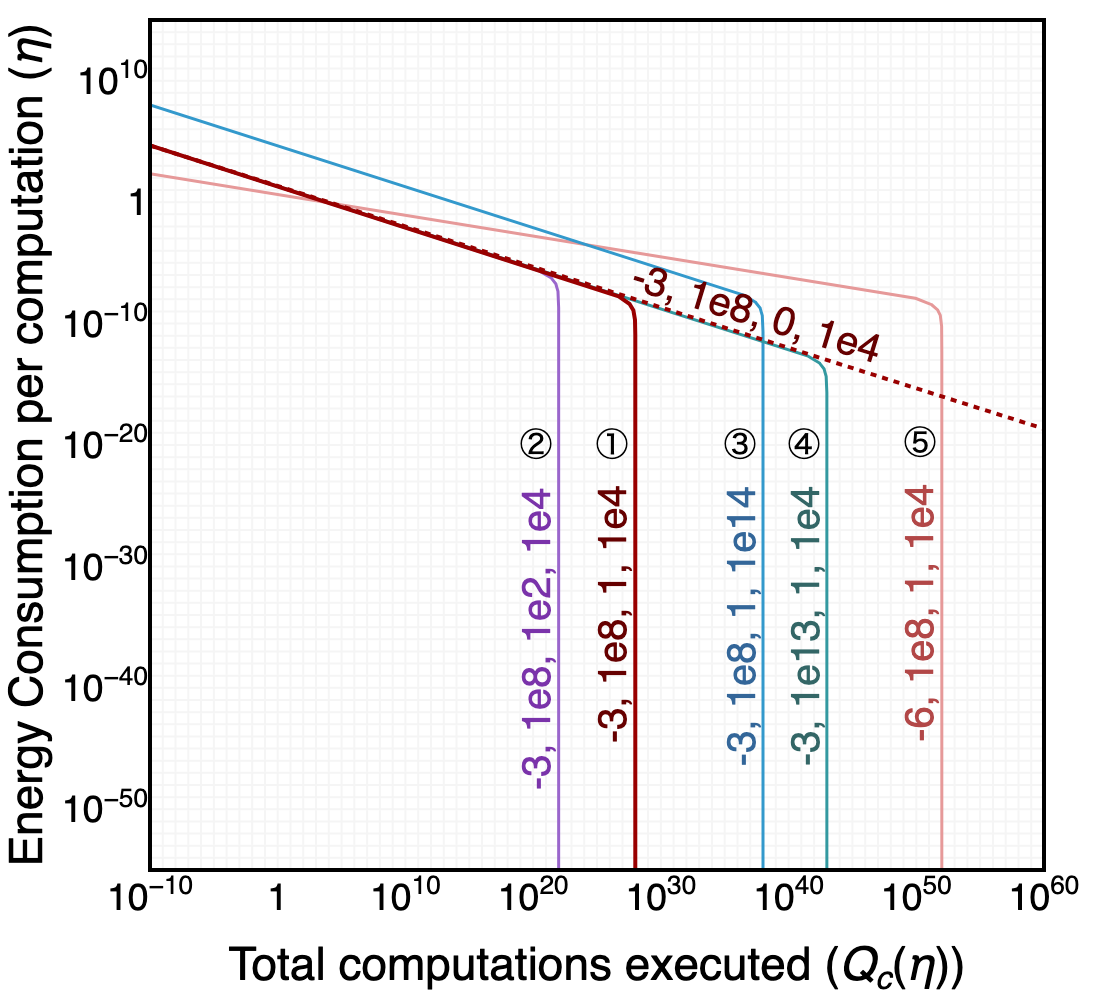

In [50]:
### Energy Intensity vs Compute considering TCO factors 

minx, maxx = -10, 60
miny, maxy = -55, 15

fig = go.Figure()

#########################################################################################################################

def add_major_log_gridlines(fig, x_exp_range=(minx, maxx), y_exp_range=(miny, maxy),
                             x_color="#F5F5F5", y_color="#F5F5F5", width=1):
    xlines = []
    ylines = []
    for exp in range(x_exp_range[0], x_exp_range[1] + 1):
        val = 10 ** exp
        xlines.append(go.Scatter(
            x=[val, val],
            y=[10 ** y_exp_range[0], 10 ** y_exp_range[1]],
            mode='lines',
            line=dict(color=x_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for exp in range(y_exp_range[0], y_exp_range[1] + 1):
        val = 10 ** exp
        ylines.append(go.Scatter(
            x=[10 ** x_exp_range[0], 10 ** x_exp_range[1]],
            y=[val, val],
            mode='lines',
            line=dict(color=y_color, width=width),
            hoverinfo='skip',
            showlegend=False
        ))
    for trace in xlines + ylines:
        fig.add_trace(trace)

add_major_log_gridlines(fig)

#########################################################################################################################


def add_trace_and_annotation(fig, x, y, x_annotate, y_annotate, line_color, text_color, text, x_offset= -0.4, y_offset=0.4, textangle=33, fontsize=15, 
                             linetype="solid", opacity=1, width=1.5, number_label='①', number_x_offset=0, number_y_offset=0):
    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        mode='lines',
        line=dict(color=line_color, dash=linetype, width=width),
        name=f'Trendline {text}',
        opacity=opacity
    ))
    fig.add_annotation(
        x=np.log10(x_annotate) + x_offset,
        y=np.log10(y_annotate) + y_offset,
        text=f"{text}",
        font=dict(size=fontsize, color=text_color),
        showarrow=False,
        textangle=textangle,
    )

    if not number_label=="":
        fig.add_annotation(
            x=np.log10(x_annotate) + number_x_offset,
            y=np.log10(y_annotate) + number_y_offset +20,
            text=number_label,
            font=dict(size=fontsize-4, color='black'),
            showarrow=False,
        )

fontsize_=20
number_labels = ["", '①', '②', '③', '④', '⑤']


#----------------------------------------------------------------------------------------------------------------------
###### Changing elasticity
## Fitline Elasticity = -6
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-6, E0=1e4, k2=1, k1=1e8, min_q=1e-10, max_q=1e53, x_val=5e51)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#E69999', text_color='#B24747',
                         text=textlabel, x_offset= -1.4, y_offset=-25, textangle=-90, fontsize=fontsize_, 
                         number_label=number_labels[5], number_x_offset=-1.4, number_y_offset=-31)


#----------------------------------------------------------------------------------------------------------------------
###### Changing k2
## Fitline Elasticity = -3, k2=1e2
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-3, E0=1e4, k2=1e2, k1=1e8, min_q=1e-10, max_q=1e23, x_val=1e21)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#9A66CC', text_color='#7A33AA',
                         text=textlabel, x_offset= -0.8, y_offset=-30, textangle=-90, fontsize=fontsize_,
                         number_label=number_labels[2], number_x_offset=-0.8, number_y_offset=-34)

#----------------------------------------------------------------------------------------------------------------------
###### Changing E0
## Fitline Elasticity = -3, E0 = 1e14
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-3, E0=1e14, k2=1, k1=1e8, min_q=1e-10, max_q=1e39, x_val=1e37)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#3399CC', text_color='#336699',
                         text=textlabel, x_offset= -0.8, y_offset=-27, textangle=-90, fontsize=fontsize_,
                         number_label=number_labels[3], number_x_offset=-0.8, number_y_offset=-32)
#----------------------------------------------------------------------------------------------------------------------
###### Changing k1
# Fitline Elasticity = -3, k1=1e13, -0.1, -22
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-3, E0=1e4, k2=1, k1=1e13, min_q=1e-10, max_q=1e44, x_val=1e42)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#3399A0', text_color='#336666',
                         text=textlabel, x_offset= -0.8, y_offset=-22, textangle=-90, fontsize=fontsize_,
                         number_label=number_labels[4], number_x_offset=-0.8, number_y_offset=-27)


#----------------------------------------------------------------------------------------------------------------------
###### Primary curve

## Fitline Elasticity = -3 
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-3, E0=1e4, k2=1, k1=1e8, min_q=1e-10, max_q=1e30, x_val=1e28)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#990000', text_color='#660000',
                         text=textlabel, x_offset= -1.8, y_offset=-11, textangle=-90, fontsize=fontsize_, width=2,
                         number_label=number_labels[1], number_x_offset=-1.8, number_y_offset=-17)

## Fitline Elasticity = -3, k2 = 0
quantity_compute, energy_intensity, x_annotate, y_annotate, textlabel = get_quantity_and_energy_intensity(elasticity=-3, E0=1e4, k2=0, k1=1e8, min_q=1e-10, max_q=1e100, x_val=1e36)
add_trace_and_annotation(fig, quantity_compute, energy_intensity, x_annotate, y_annotate, line_color='#990000', text_color='#660000',
                         text=textlabel, x_offset= 1.6, y_offset=1.6, textangle=17, fontsize=fontsize_, 
                         linetype="dot", width=2, number_label=number_labels[0])

#########################################################################################################################


fig.update_layout(
    width=550,  
    height=500,
    xaxis=dict(
        type='log',
        dtick=10,
        exponentformat="power",
        showexponent="all",
        title=dict(
            text= "Total computations executed (<i>Q<sub>c</sub></i>(<i>η</i>))", 
            font=dict(size=23)),
        range=[minx, maxx],
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=15)
    ),
    yaxis=dict(
        type='log',
        dtick=10,
        exponentformat="power",
        showexponent="all",
        title=dict(
            text= "Energy Consumption per computation (<i>η</i>)", 
            standoff=5,
            font=dict(size=23)),
        range=[miny, maxy], 
        showgrid=False,
        zeroline=False,
        tickfont=dict(size=15)
    ),
    font=dict(family='Helvetica', size=10, color='black'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    margin=dict(l=10, r=10, t=10, b=10),
    
    shapes=[dict(
        type='rect',
        x0=0, x1=1, y0=0, y1=1,
        xref='paper', yref='paper',
        line=dict(color='black', width=2)
    )]
)

filename = "graphs/energy_intensity__vs__compute"
fig.write_image(f"{filename}.png", scale=2)
fig.write_image(f"{filename}.pdf", engine="kaleido", scale=2)

display(Image(filename=f"{filename}.png"))